# sci-Plex3 dataset embeddings

PCA, UMAP, and PHATE visualizations of the ~100k cell training set,
colored by cell type, perturbation, dose, and control status.

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hydra.utils import instantiate
from omegaconf import OmegaConf
from sklearn.decomposition import PCA

# load datamodule from an existing run config
experiment_name = "sciplex_ae_deg_log1p_recon"
runs_root = Path("artifacts/runs")
run_root = runs_root / experiment_name
run_dirs = sorted(p for p in run_root.glob("*") if p.is_dir())
if not run_dirs:
    raise FileNotFoundError(f"No runs found under {run_root}")
run_dir = run_dirs[-1]
cfg = OmegaConf.load(run_dir / "run_config.yaml")

datamodule = instantiate(
    cfg.data,
    data=OmegaConf.to_container(cfg.data, resolve=True),
    splitter=OmegaConf.to_container(cfg.splitter, resolve=True),
    space=OmegaConf.to_container(cfg.space, resolve=True),
    evaluation_space=OmegaConf.to_container(cfg.evaluation_space, resolve=True),
    condition=OmegaConf.to_container(cfg.condition, resolve=True),
    paths=OmegaConf.to_container(cfg.paths, resolve=True),
    ae_geometry=OmegaConf.to_container(cfg.ae_geometry, resolve=True),
    task=OmegaConf.to_container(cfg.task, resolve=True),
    predict=OmegaConf.to_container(cfg.predict, resolve=True),
    trainer=OmegaConf.to_container(cfg.trainer, resolve=True),
    _recursive_=False,
)
datamodule.setup("fit")

# get all cells (train + test)
held_out_mask = np.asarray(datamodule.masks["is_held_out"], dtype=bool)
adata = datamodule.adata_full

# transform to normalized log1p on DEG+HVG genes
x_all, _, feature_names = datamodule.train_pipeline.transform(adata, device="cpu")
x_all = np.asarray(x_all, dtype=np.float32)

obs = adata.obs.copy().reset_index(drop=True)
obs["split"] = np.where(held_out_mask, "test", "train")
obs["is_control"] = obs["vehicle"].astype(str) == "1"

print(f"cells: {x_all.shape[0]}, genes: {x_all.shape[1]}")
print(f"cell types: {obs['cell_type'].unique().tolist()}")
print(f"perturbations: {obs['product_name'].nunique()}")
print(f"train: {(~held_out_mask).sum()}, test: {held_out_mask.sum()}")

cells: 100000, genes: 6396
cell types: ['K562', 'A549', 'MCF7']
perturbations: 189
train: 87775, test: 12225


In [2]:
# PCA (fast, always available)
print("fitting PCA...")
pca = PCA(n_components=50)
x_pca = pca.fit_transform(x_all)
print(f"PCA variance explained (50 PCs): {pca.explained_variance_ratio_.sum():.4f}")

# store 2D for plotting
emb_pca = x_pca[:, :2]

fitting PCA...
PCA variance explained (50 PCs): 0.1627


In [3]:
# UMAP on PCA-50
import umap

print("fitting UMAP on PCA-50...")
reducer_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.3, random_state=42)
emb_umap = reducer_umap.fit_transform(x_pca)
print("done")

fitting UMAP on PCA-50...


/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


done


In [4]:
# PHATE on PCA-50
import phate

print("fitting PHATE on PCA-50...")
op_phate = phate.PHATE(n_components=2, knn=15, random_state=42, n_jobs=-1)
emb_phate = op_phate.fit_transform(x_pca)
print("done")

fitting PHATE on PCA-50...
Calculating PHATE...
  Running PHATE on 100000 observations and 50 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 3.14 seconds.
    Calculating affinities...
    Calculated affinities in 1.52 seconds.
  Calculated graph and diffusion operator in 4.90 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 26.28 seconds.
    Calculating KMeans...
    Calculated KMeans in 20.32 seconds.
  Calculated landmark operator in 46.61 seconds.
  Calculating optimal t...
    Automatically selected t = 21
  Calculated optimal t in 27.12 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.30 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 2.26 seconds.
Calculated PHATE in 82.10 seconds.
done


In [5]:
# helper for scatter plots
def scatter_grid(embeddings, obs_df, color_by, titles=None, figsize=(18, 5), s=0.5, alpha=0.3, shuffle=True):
    """scatter plot grid: one row per color_by, one column per embedding method"""
    method_names = list(embeddings.keys())
    n_cols = len(method_names)
    n_rows = len(color_by)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize[0], figsize[1] * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    # shuffle indices for better overlapping visibility
    n = len(obs_df)
    if shuffle:
        rng = np.random.RandomState(42)
        order = rng.permutation(n)
    else:
        order = np.arange(n)

    for col_idx, method in enumerate(method_names):
        emb = embeddings[method]
        for row_idx, col_name in enumerate(color_by):
            ax = axes[row_idx, col_idx]
            values = obs_df[col_name].to_numpy()

            if pd.api.types.is_numeric_dtype(obs_df[col_name]) and obs_df[col_name].nunique() > 10:
                # continuous coloring
                sc = ax.scatter(
                    emb[order, 0], emb[order, 1], c=values[order], cmap="viridis", s=s, alpha=alpha, rasterized=True
                )
                plt.colorbar(sc, ax=ax, shrink=0.7)
            else:
                # categorical coloring
                categories = sorted(obs_df[col_name].astype(str).unique())
                if len(categories) <= 20:
                    cmap = plt.cm.tab20
                    colors = {cat: cmap(i / max(len(categories) - 1, 1)) for i, cat in enumerate(categories)}
                    for cat in categories:
                        mask = obs_df[col_name].astype(str).to_numpy() == cat
                        idx = order[np.isin(order, np.where(mask)[0])]
                        ax.scatter(
                            emb[idx, 0], emb[idx, 1], c=[colors[cat]], s=s, alpha=alpha, label=cat, rasterized=True
                        )
                    ax.legend(fontsize=6, markerscale=4, loc="best", framealpha=0.7)
                else:
                    # too many categories, use hash-based coloring, no legend
                    cat_codes = pd.Categorical(obs_df[col_name].astype(str)).codes
                    sc = ax.scatter(
                        emb[order, 0],
                        emb[order, 1],
                        c=cat_codes[order],
                        cmap="tab20",
                        s=s,
                        alpha=alpha,
                        rasterized=True,
                    )

            ax.set_title(f"{method} — {col_name}", fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()

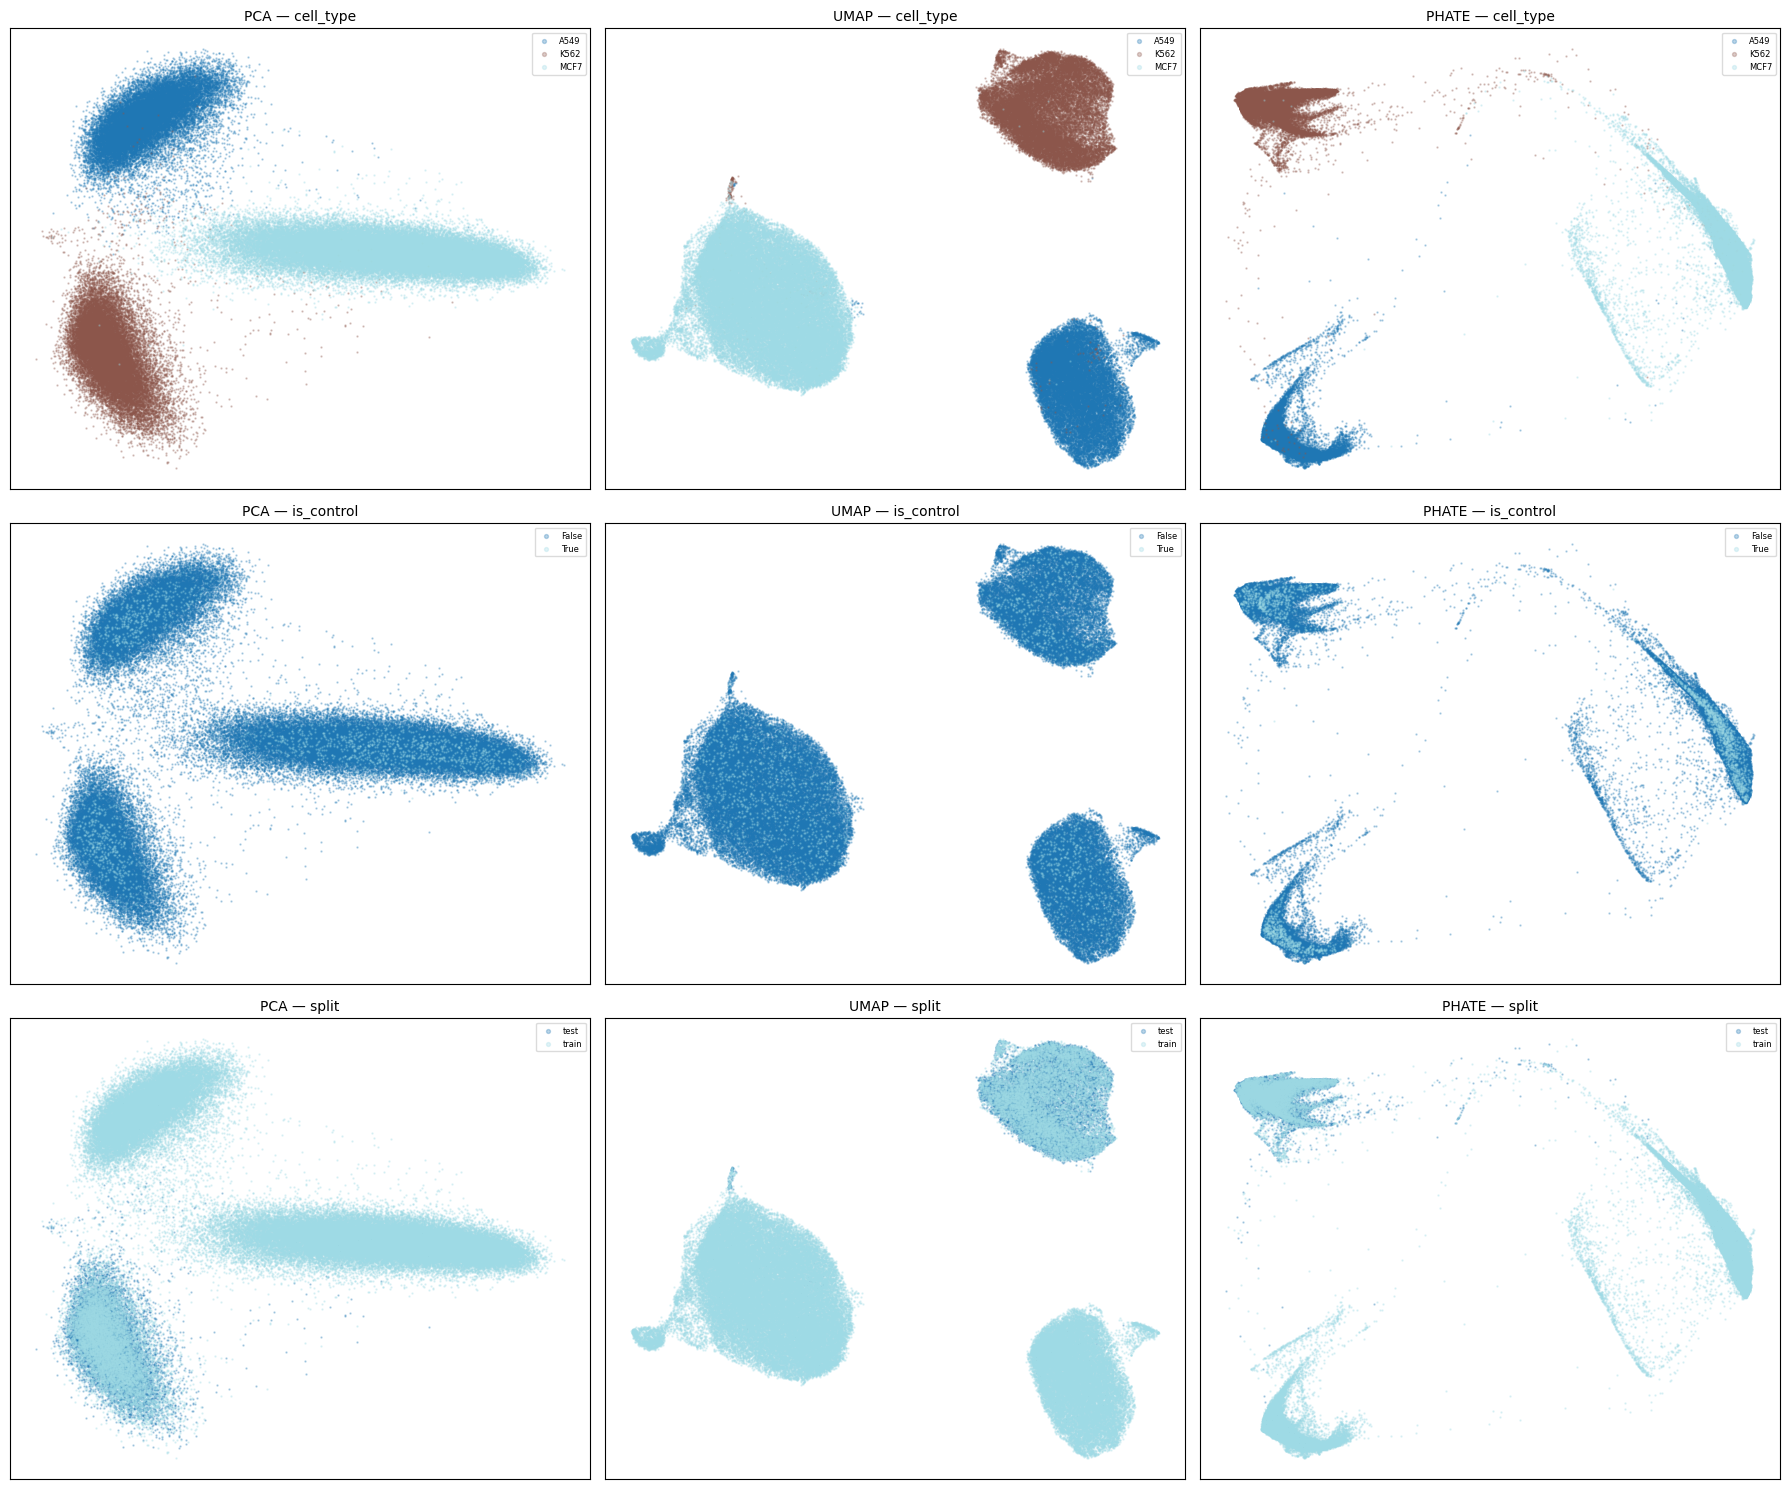

In [6]:
embeddings = {"PCA": emb_pca, "UMAP": emb_umap, "PHATE": emb_phate}

# main visualization: cell type, control status, split
scatter_grid(embeddings, obs, ["cell_type", "is_control", "split"])

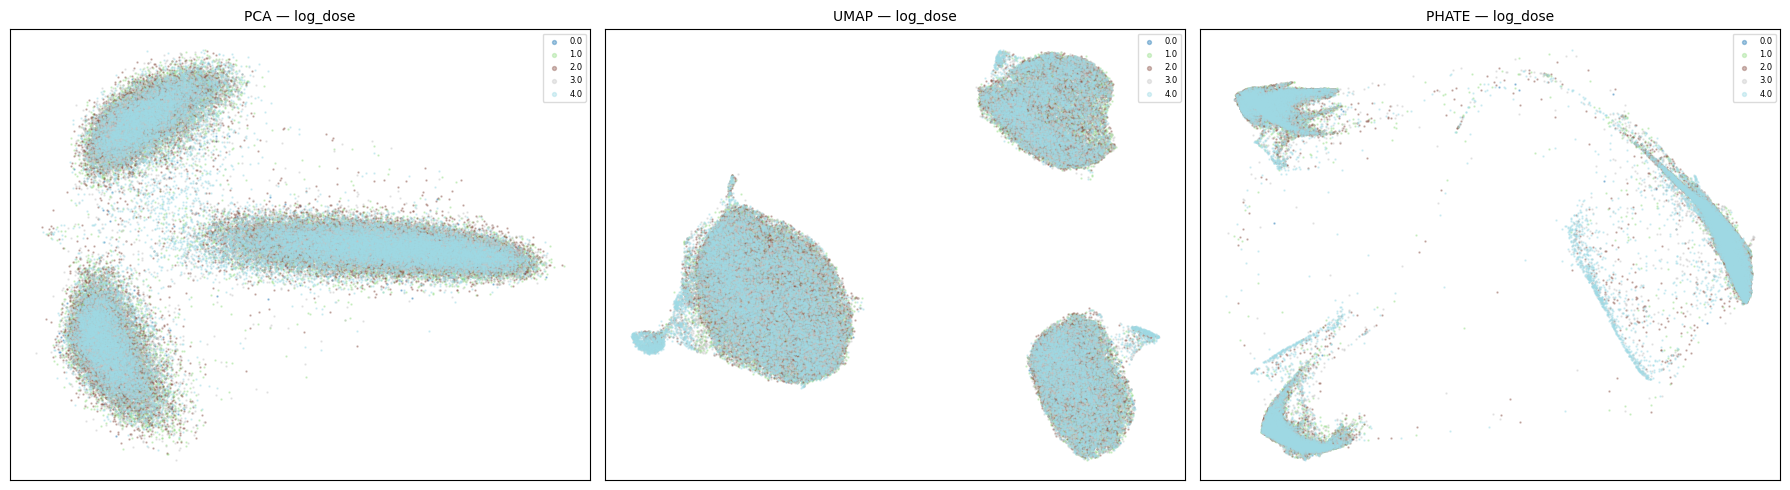

In [7]:
# dose (as numeric for continuous coloring)
obs["dose_num"] = pd.to_numeric(obs["dose"], errors="coerce")
obs["log_dose"] = np.log10(obs["dose_num"].clip(lower=1))

scatter_grid(embeddings, obs, ["log_dose"], s=0.5, alpha=0.4)


--- A549 (24549 cells) ---


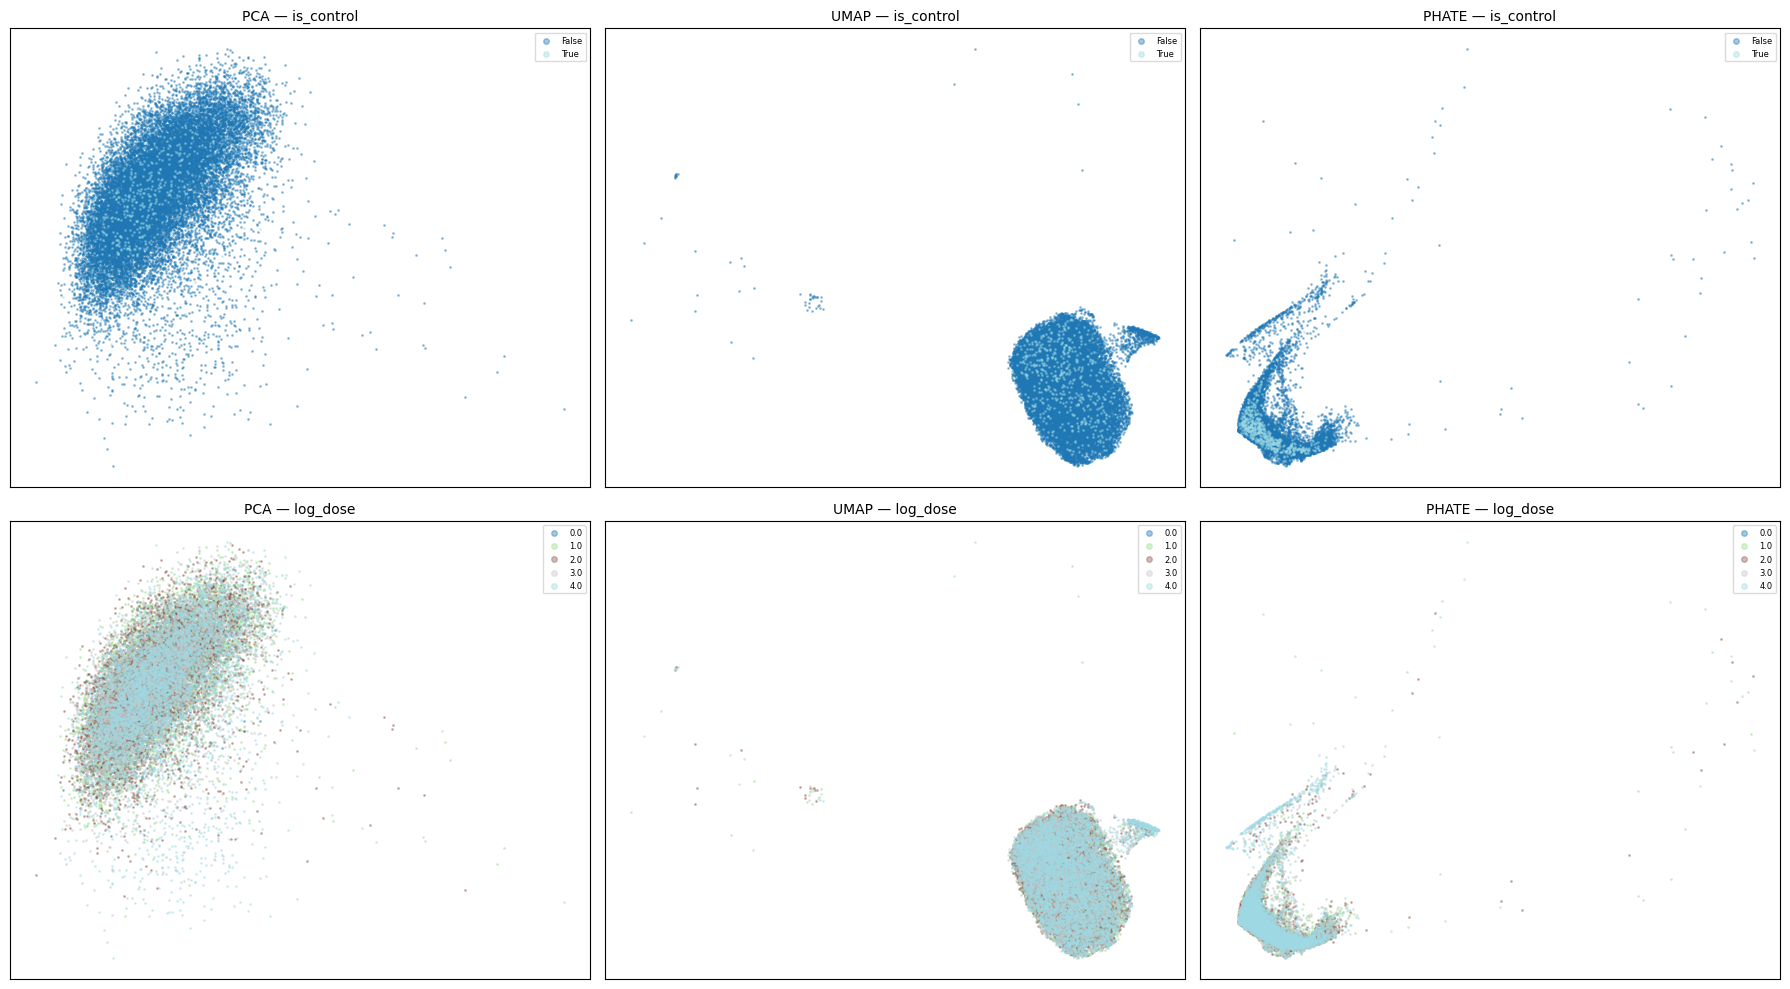


--- K562 (25151 cells) ---


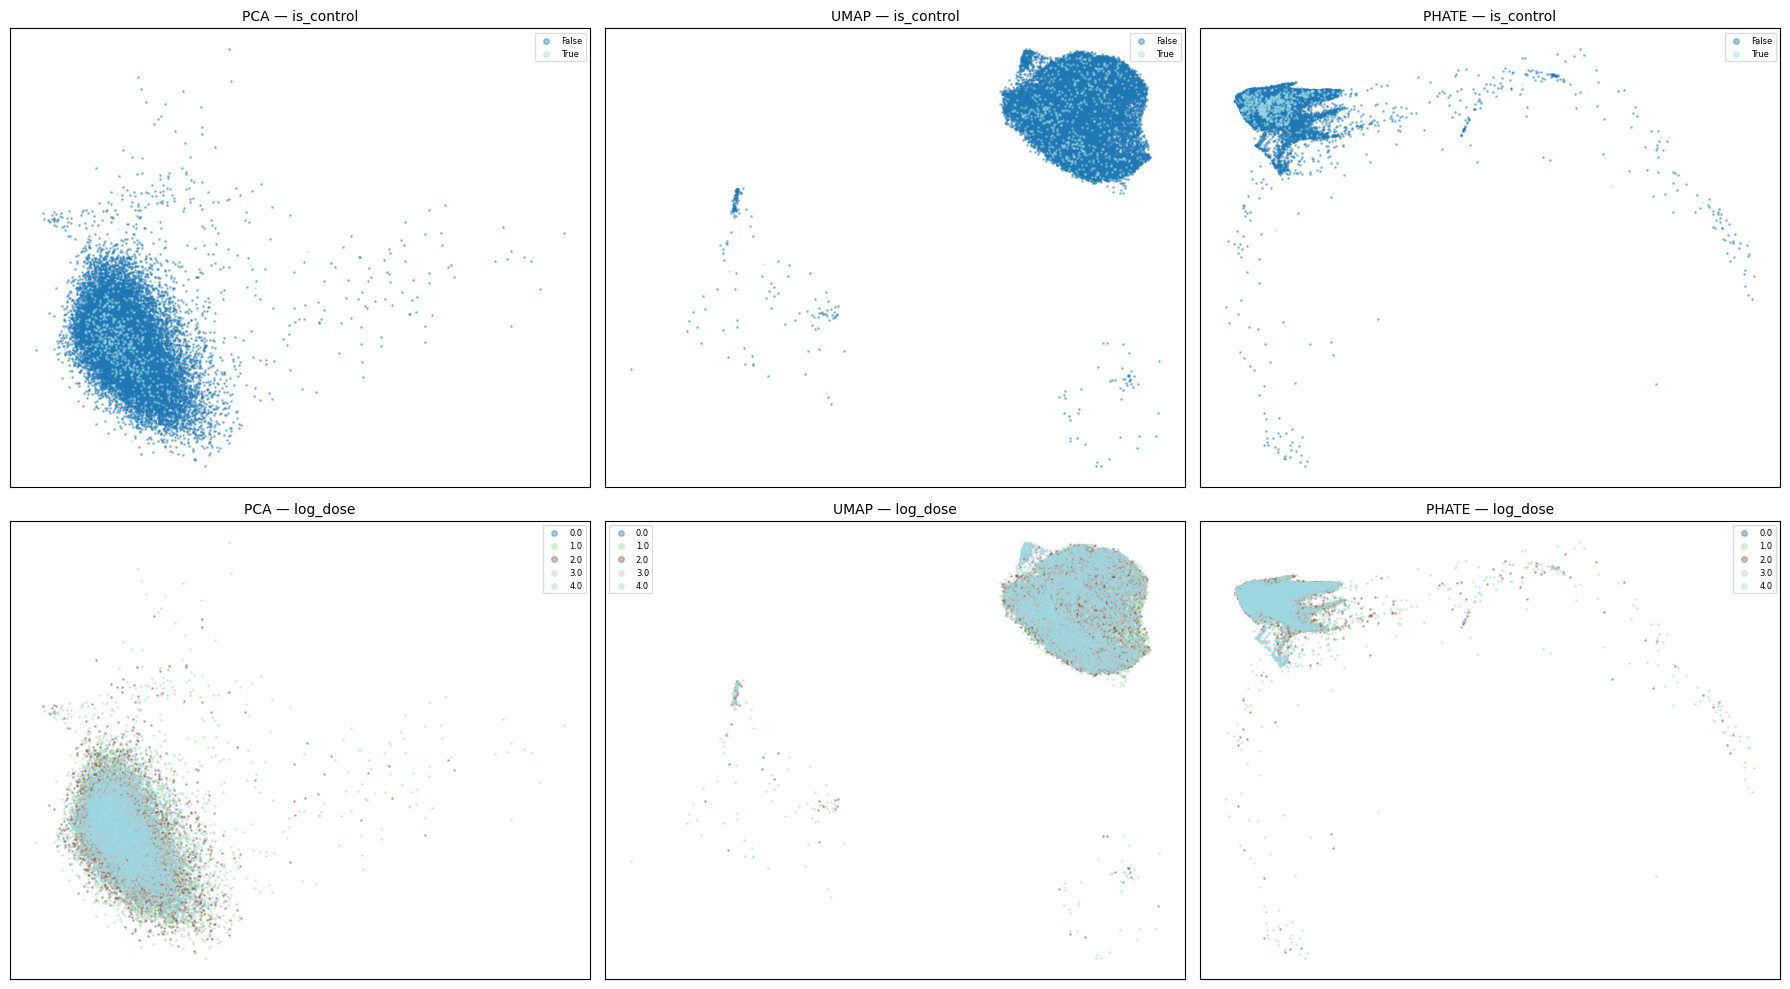


--- MCF7 (50300 cells) ---


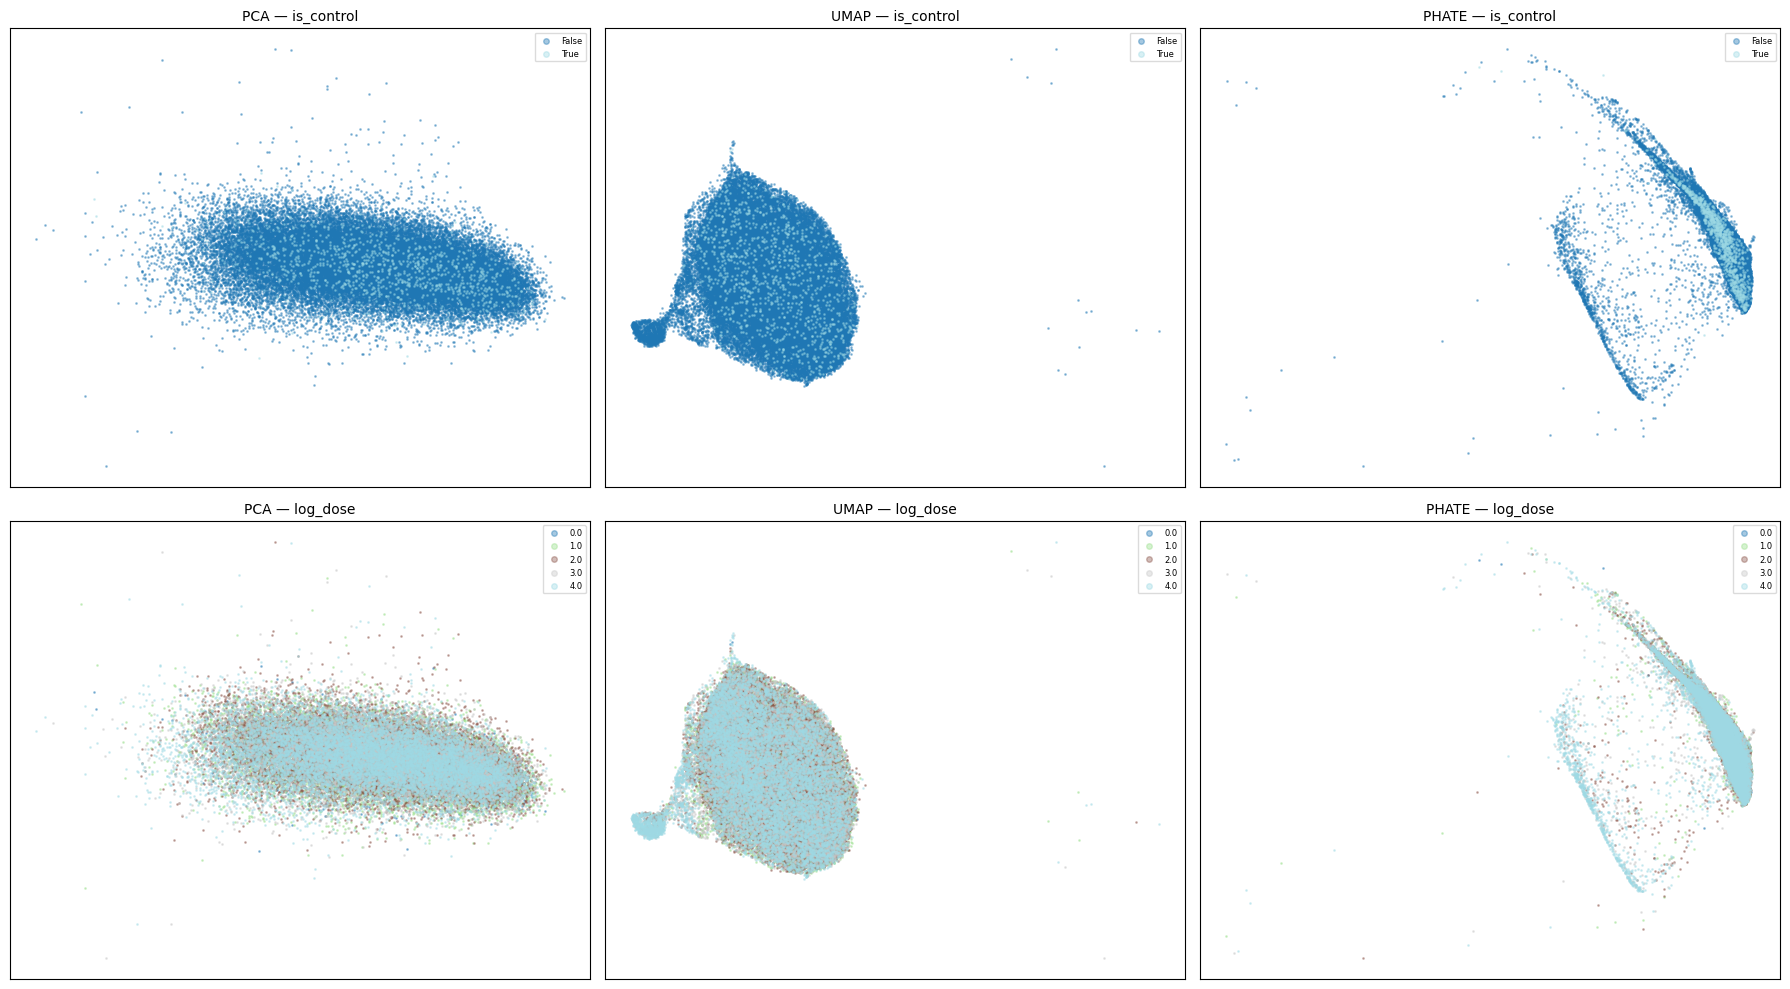

In [8]:
# per-cell-type embeddings (separate plots for each cell type)
cell_types = sorted(obs["cell_type"].astype(str).unique())

for ct in cell_types:
    ct_mask = obs["cell_type"].astype(str).to_numpy() == ct
    ct_obs = obs.loc[ct_mask].reset_index(drop=True)
    ct_embeddings = {name: emb[ct_mask] for name, emb in embeddings.items()}

    print(f"\n--- {ct} ({ct_mask.sum()} cells) ---")
    scatter_grid(ct_embeddings, ct_obs, ["is_control", "log_dose"], s=1.0, alpha=0.4)

top 10 perturbations: ['Busulfan ', 'Baricitinib (LY3009104, INCB028050)', 'RG108', 'Tubastatin A HCl', 'PD98059', 'GSK-LSD1 2HCl', 'Cerdulatinib (PRT062070, PRT2070)', 'Entacapone', 'Tacedinaline (CI994)', 'BRD4770']


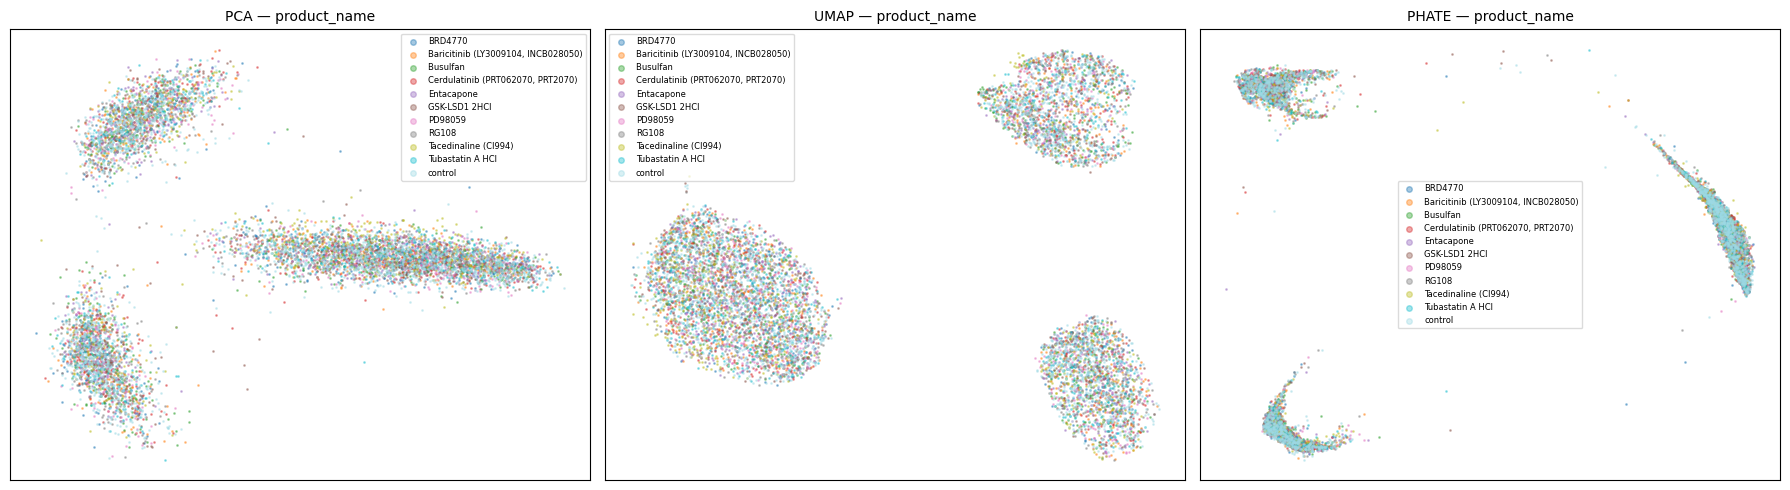

In [10]:
# top perturbations by cell count (highlight specific drugs)
pert_counts = obs.loc[~obs["is_control"], "product_name"].value_counts()
top_perts = pert_counts.head(10).index.tolist()
print(f"top 10 perturbations: {top_perts}")

# filter to top perturbations + controls for cleaner visualization
top_mask = obs["product_name"].isin(top_perts) | obs["is_control"]
top_obs = obs.loc[top_mask].copy().reset_index(drop=True)
top_obs["product_name"] = top_obs["product_name"].astype(str)
top_obs.loc[top_obs["is_control"], "product_name"] = "control"
top_embeddings = {name: emb[top_mask] for name, emb in embeddings.items()}

scatter_grid(top_embeddings, top_obs, ["product_name"], s=1.0, alpha=0.4)